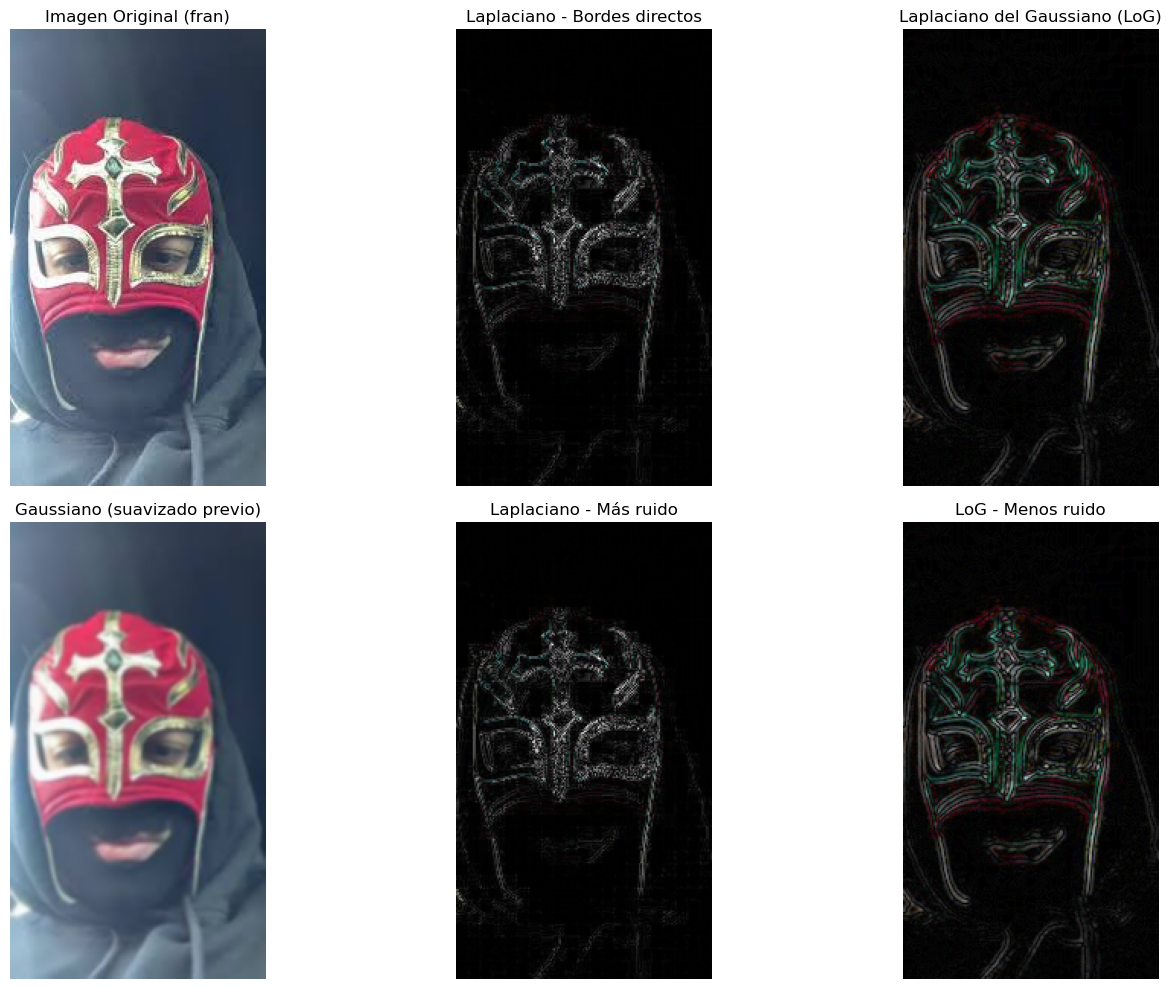

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('fran.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Este filtro detecta cambios de intensidad rápidos (bordes)
laplaciano = cv2.Laplacian(gray, cv2.CV_64F)

# Convertimos a valores absolutos porque el Laplaciano puede dar valores negativos
laplaciano_abs = np.absolute(laplaciano)

# Normalizamos a 0-255 para poder visualizarlo correctamente
laplaciano_norm = cv2.normalize(laplaciano_abs, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)


# Esto hace que el detector de bordes sea menos sensible al ruido
gaussiano = cv2.GaussianBlur(gray, (5, 5), 0)


# Ahora detectamos bordes sobre la imagen ya suavizada
log = cv2.Laplacian(gaussiano, cv2.CV_64F)

# Convertimos a valores absolutos y normalizamos
log_abs = np.absolute(log)
log_norm = cv2.normalize(log_abs, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)


plt.figure(figsize=(15, 10))


plt.subplot(2, 3, 1)
plt.imshow(gray)
plt.title('Imagen Original (fran)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(laplaciano_norm, cmap='gray')
plt.title('Laplaciano - Bordes directos')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(log_norm, cmap='gray')
plt.title('Laplaciano del Gaussiano (LoG)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(gaussiano, cmap='gray')
plt.title('Gaussiano suavizado')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(laplaciano_norm, cmap='gray')
plt.title('Laplaciano - Más ruido')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(log_norm, cmap='gray')
plt.title('LoG - Menos ruido')
plt.axis('off')

plt.tight_layout()
plt.show()

